In [1]:
import time
from typing import Iterator

import numpy
from smodels.decomposition.theorySMS import TheorySMS
from smodels.base.genericSMS import GenericSMS
from smodels.decomposition.topologyDict import TopologyDict
from smodels.base.particleNode import ParticleNode
from smodels.base.physicsUnits import fb, GeV
from smodels.decomposition.exceptions import SModelSDecompositionError as SModelSError
from smodels.base.smodelsLogging import logger
from itertools import product
from smodels.base import runtime
from smodels.decomposition import decomposer
from smodels.base.physicsUnits import fb, GeV, TeV
from smodels.matching.theoryPrediction import theoryPredictionsFor,TheoryPredictionsCombiner
from smodels.experiment.databaseObj import Database
from smodels.base.smodelsLogging import setLogLevel
from smodels.tools.particlesLoader import load
from smodels.share.models.SMparticles import SMList
from smodels.base.model import Model
from smodels.base.particleNode import ParticleNode
from smodels.decomposition.decomposerNew import decomposeNew,build_subtree_cache
import itertools
import time
import numpy as np
setLogLevel("info")

In [2]:
# Load the BSM model
runtime.modelFile = "nmssmPoints/000.slha"
BSMList = load()
model = Model(BSMparticles=BSMList, SMparticles=SMList)
slhafile = 'nmssmPoints/022.slha'
model.updateParticles(inputFile=slhafile,ignorePromptQNumbers = ['eCharge','spin'],promptWidth=1e-14*GeV)


INFO in model.updateParticles() in 428: Loaded 58 BSM particles


In [3]:
# def compressDecay(decay, minmassgap=10.0*GeV):
#     mom,daughters,_ = decay
#     if mom.isSM:
#         return False
#     if not mom.particle.isPrompt():
#         return False
    
#     bsmDaughters = [d for d in daughters if not (hasattr(d, 'isSM') and d.isSM)]
#     if len(bsmDaughters) != 1:
#            return False
#     bsmDaughter = bsmDaughters[0]
#     massDiff = mom.mass - bsmDaughter.mass    
#     if massDiff >= minmassgap:
#         return False

#     return bsmDaughter


# for (mom,daughters,br) in decays:
            
#     if br < minBR:
#         continue
#     daughter_choices = []
#     for daughter in daughters:
#         daughter_subtrees, memo = build_subtree_cache(daughter, memo, visiting, minBR)
#         daughter_choices.append(daughter_subtrees)
#     if massCompress:
#         compDecay = compressDecay((mom,daughters,br), mingap)
#         if compDecay is not False:
#             subtrees.append(memo[compDecay.particle])
        

        

In [4]:
massCompress = True
invisibleCompress = True

# Set main options for decomposition
sigmacut = 0.01*fb
mingap = 10.*GeV
mingapISR = 10.0*GeV


In [5]:
n2 = model.getParticle(pdg=1000023)
n1 = model.getParticle(pdg=1000022)
print(n2.mass, n1.mass)
print(n2.isPrompt(), n1.isPrompt())
print(n2.totalwidth, n1.totalwidth)

1.51E+01 [GeV] 1.14E+01 [GeV]
True False
3.31E-13 [GeV] 0.00E+00 [GeV]


1


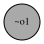

In [6]:
sub_trees_n1,_ = build_subtree_cache(ParticleNode(particle=n1),memo={},massCompress=False)
print(len(sub_trees_n1))
for t in sub_trees_n1:
    t.draw()

In [7]:
p = model.getParticle(pdg=1000023)
pNode = ParticleNode(particle=p)
sub_trees,_ = build_subtree_cache(pNode,massCompress=False)
print(len(sub_trees))

11


In [8]:
sub_treesB,memo = build_subtree_cache(pNode,memo={},massCompress=True,minmassgap=4*GeV)
print(len(sub_treesB))

12


In [9]:
tA = sub_treesB[0]
tB = sub_treesB[2]
print(tA,tB,tA==tB)

(~o2 > ~o1,mu-,mu+) (~o2 > ~o1,photon) False


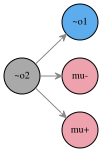

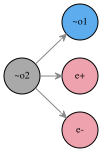

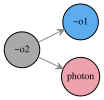

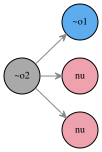

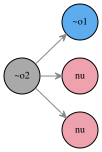

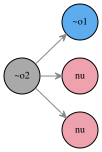

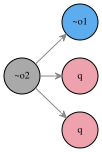

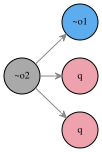

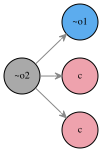

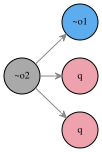

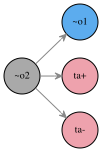

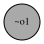

In [11]:
for t in sub_treesB:
    t.draw()